# FairLoan Assist — ML for Social Good

**Mission domain:** Financial Inclusion  
**Course:** MCA 521-4 Machine Learning | CIA 3

# 1. Real-World Impact Framing

## Problem and beneficiaries
Micro-loan providers need to identify applications that may need an affordability review without automatically excluding underserved people. The beneficiaries are loan applicants, who can receive better-informed support, and loan officers, who can prioritise limited review time.

## Prediction target and impact
The target is **historical bad-credit/default outcome** (`1 = bad`, `0 = good`) for one anonymised credit application. A practical pilot would measure: default recall, false-positive rate, approval and appeal outcomes, and error-rate gaps between permitted audit groups. The goal is safer review prioritisation without reducing fair access.

## Why ML and responsible-use
Credit-risk patterns depend on several interacting factors (requested amount, repayment duration, credit history, savings and employment). Ensemble ML can learn non-linear patterns and is compared against a simple baseline. This is **decision support only**: no automated approval, denial, pricing, or ranking; a trained person must review every case and provide correction/appeal routes.

## Dataset and unit of analysis
**Dataset:** OpenML `credit-g`, originally UCI Statlog (German Credit Data), 1,000 anonymised historical credit applications. **Unit:** one application. **Source:** https://www.openml.org/d/31 (Dua & Graff, 2019, UCI Machine Learning Repository). It contains no direct identifiers, but proxy and historical-bias risks remain.

# 2. Data Wrangling and Feature Engineering

## Preprocessing decisions

- Duplicates are removed; non-positive age, duration, and credit amount are invalid and become missing.
- Numeric missing values use the training-fold median; categorical missing values use the training-fold mode.
- Numeric features are standardised; categorical features are one-hot encoded.
- `credit_per_month = credit_amount / duration` is a transparent affordability proxy.
- Balanced class weights address the minority default class.
- `personal_status` is excluded from the model. It is kept only as a limited post-hoc audit group.
- A stratified 60/20/20 train/validation/test split preserves the default proportion. The test set remains untouched until final evaluation.

All transforms are inside a scikit-learn `Pipeline`, so medians, modes, scaling, and encoding are learned only from training folds.

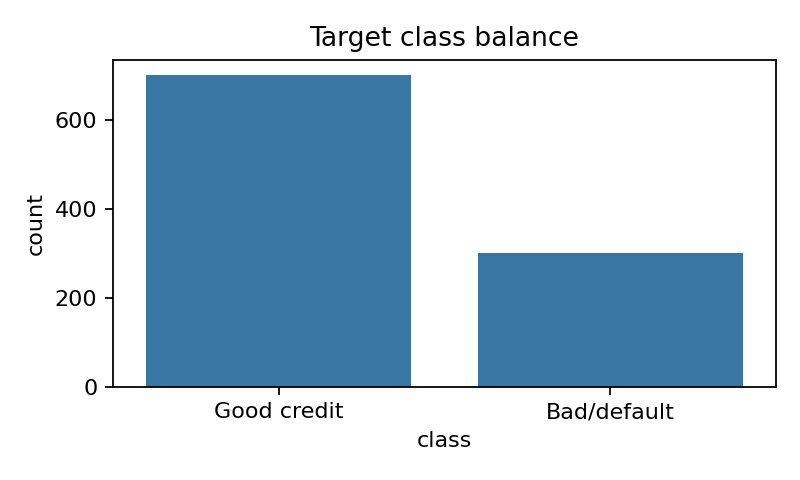

In [ ]:
# Q2 — load, audit, clean, engineer features, and EDA
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import (
    AdaBoostClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
OUT = Path("outputs"); FIG = OUT / "figures"
OUT.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)

bunch = fetch_openml(name="credit-g", version=1, as_frame=True, parser="auto")
X = bunch.data.copy()
y = (bunch.target == "bad").astype(int)  # 1 = historical bad/default outcome
before = len(X)
keep = ~X.duplicated()
X, y = X.loc[keep].reset_index(drop=True), y.loc[keep].reset_index(drop=True)
for col in ["duration", "credit_amount", "age", "installment_commitment"]:
    X[col] = pd.to_numeric(X[col], errors="coerce")
X.loc[X.duration <= 0, "duration"] = np.nan
X.loc[X.credit_amount <= 0, "credit_amount"] = np.nan
X.loc[X.age <= 0, "age"] = np.nan
X["credit_per_month"] = X.credit_amount / X.duration
# Female must be checked first: the substring 'male' occurs in 'female'.
audit_group = pd.Series(np.where(X.personal_status.astype(str).str.startswith("female"), "female", "male"))
X = X.drop(columns="personal_status")

audit = {"rows_before": before, "rows_after": len(X), "duplicates_removed": before-len(X), "missing_values": X.isna().sum().to_dict()}
(OUT / "data_audit.json").write_text(json.dumps(audit, indent=2))
print(json.dumps(audit, indent=2))

plt.figure(figsize=(5,3)); sns.countplot(x=y, color="#2878B5")
plt.xticks([0,1],["Good credit", "Bad/default"]); plt.title("Target class balance"); plt.tight_layout()
plt.savefig(FIG / "target_balance.png", dpi=160); plt.show()


In [ ]:
# Q2 — reproducible split and leakage-safe preprocessor
X_dev, X_test, y_dev, y_test, g_dev, g_test = train_test_split(X, y, audit_group, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=RANDOM_STATE)
(OUT / "split_summary.json").write_text(json.dumps({"train":len(X_train), "validation":len(X_val), "test":len(X_test), "strategy":"stratified 60/20/20; CV on development data only"}, indent=2))

numeric = X_train.select_dtypes(include=np.number).columns.tolist()
categorical = [c for c in X_train.columns if c not in numeric]
def preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical),
    ], verbose_feature_names_out=False)
print({"train":len(X_train), "validation":len(X_val), "test":len(X_test), "numeric_features":len(numeric), "categorical_features":len(categorical)})


# 3. Ensemble Architecture, Tuning, and Comparison

## Models

1. **Baseline:** Logistic Regression with balanced class weights.
2. **Bagging:** Random Forest, tuned with randomized search over tree count, depth, leaf size, and features per split.
3. **Boosting:** AdaBoost with shallow balanced decision trees.
4. **Heterogeneous ensembles:** soft voting and stacking of Logistic Regression, Random Forest, and AdaBoost.

## Correct validation
Random-Forest tuning uses stratified 5-fold CV on development data only. Stacking also creates its meta-model training inputs from out-of-fold predictions (`cv=5`), preventing meta-learning leakage. All models are scored once on the same untouched test set.

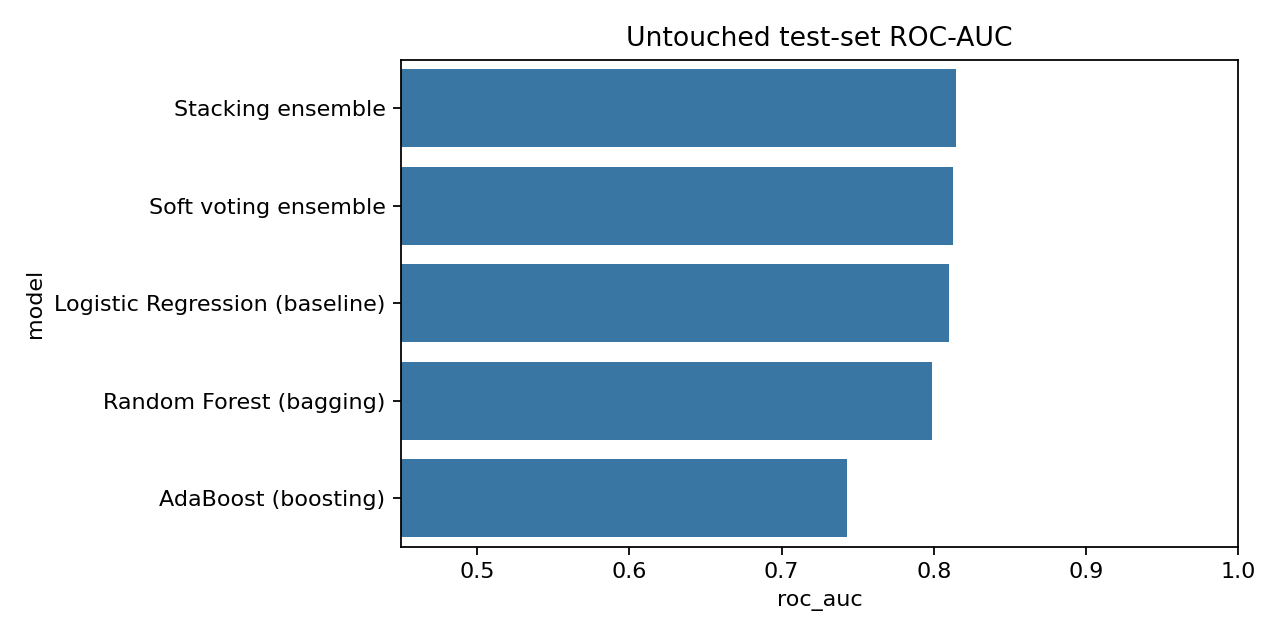

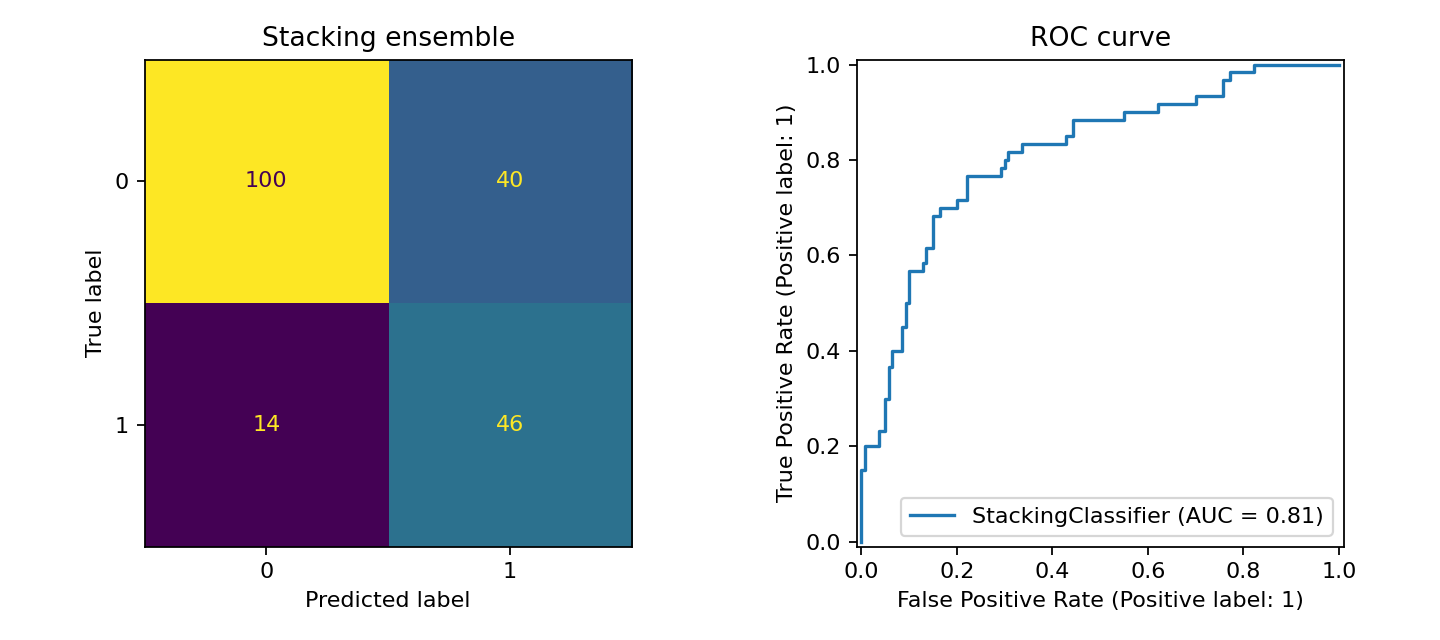

In [ ]:
# Q3 — train, tune, compare and save the best pipeline
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
baseline = Pipeline([("prep", preprocessor()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))])
rf = Pipeline([("prep", preprocessor()), ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))])
rf_search = RandomizedSearchCV(
    rf,
    {"model__n_estimators":[250,400], "model__max_depth":[4,7,None], "model__min_samples_leaf":[1,3,6], "model__max_features":["sqrt",0.6]},
    n_iter=8, scoring="roc_auc", cv=cv, n_jobs=-1, random_state=RANDOM_STATE)
rf_search.fit(X_dev, y_dev)
rf_best = rf_search.best_estimator_

boost = Pipeline([("prep", preprocessor()), ("model", AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=RANDOM_STATE),
    n_estimators=200, learning_rate=0.05, random_state=RANDOM_STATE))])
boost.fit(X_dev, y_dev)

stack = StackingClassifier(
    estimators=[("lr", baseline), ("rf", rf_best), ("ada", boost)],
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced"),
    stack_method="predict_proba", cv=cv, n_jobs=-1)
stack.fit(X_dev, y_dev)
vote = VotingClassifier(estimators=[("lr", baseline), ("rf", rf_best), ("ada", boost)], voting="soft", n_jobs=-1)
vote.fit(X_dev, y_dev)

models = {"Logistic Regression (baseline)": baseline.fit(X_dev,y_dev), "Random Forest (bagging)":rf_best, "AdaBoost (boosting)":boost, "Stacking ensemble":stack, "Soft voting ensemble":vote}
def metrics(name, model):
    prob = model.predict_proba(X_test)[:,1]; pred = (prob >= 0.5).astype(int)
    return {"model":name, "accuracy":accuracy_score(y_test,pred), "roc_auc":roc_auc_score(y_test,prob), "f1":f1_score(y_test,pred), "precision":precision_score(y_test,pred,zero_division=0), "recall":recall_score(y_test,pred,zero_division=0)}
results = pd.DataFrame([metrics(name, model) for name,model in models.items()]).sort_values("roc_auc", ascending=False)
best_name = results.iloc[0].model; best = models[best_name]
results.to_csv(OUT / "model_comparison.csv", index=False)
joblib.dump(best, OUT / "best_model.joblib")
(OUT / "model_metadata.json").write_text(json.dumps({"best_model":best_name,"threshold":0.5,"target":"1 = historical bad/default outcome"},indent=2))
display(results.style.format({c:"{:.3f}" for c in results.columns if c != "model"}))
print("Best model:", best_name)

plt.figure(figsize=(8,4)); sns.barplot(data=results, x="roc_auc", y="model", color="#2878B5"); plt.xlim(0.45,1); plt.title("Untouched test-set ROC-AUC"); plt.tight_layout(); plt.savefig(FIG / "model_comparison.png",dpi=160); plt.show()
fig, ax = plt.subplots(1,2,figsize=(9,4)); ConfusionMatrixDisplay.from_estimator(best,X_test,y_test,ax=ax[0],colorbar=False); ax[0].set_title(best_name); RocCurveDisplay.from_estimator(best,X_test,y_test,ax=ax[1]); ax[1].set_title("ROC curve"); plt.tight_layout(); plt.savefig(FIG / "test_diagnostics.png",dpi=160); plt.show()


# 4. Model Explainability and Ethics

## Explainability method
Permutation importance is a model-agnostic global method: it measures the ROC-AUC reduction when a raw feature is shuffled. The local explanation is a one-field counterfactual: it replaces one value with a typical training value and measures the prediction change. Both explain the complete deployed pipeline, not a separate simplified model.

## Ethics and deployment limits

- Historical repayment labels may encode past exclusion; group comparisons are descriptive, not proof of fairness.
- `personal_status` is excluded from prediction; the limited sex-proxy audit reports selection rate, default recall, and false-positive rate.
- False positives may unfairly burden/exclude applicants; false negatives may cause unaffordable lending. Thresholds require policy and human review.
- Collect only consented/minimised data; secure it, enable correction and appeal, monitor drift/calibration/group gaps, and suspend on harm.
- Dataset results are educational; validate on representative local data before deployment.

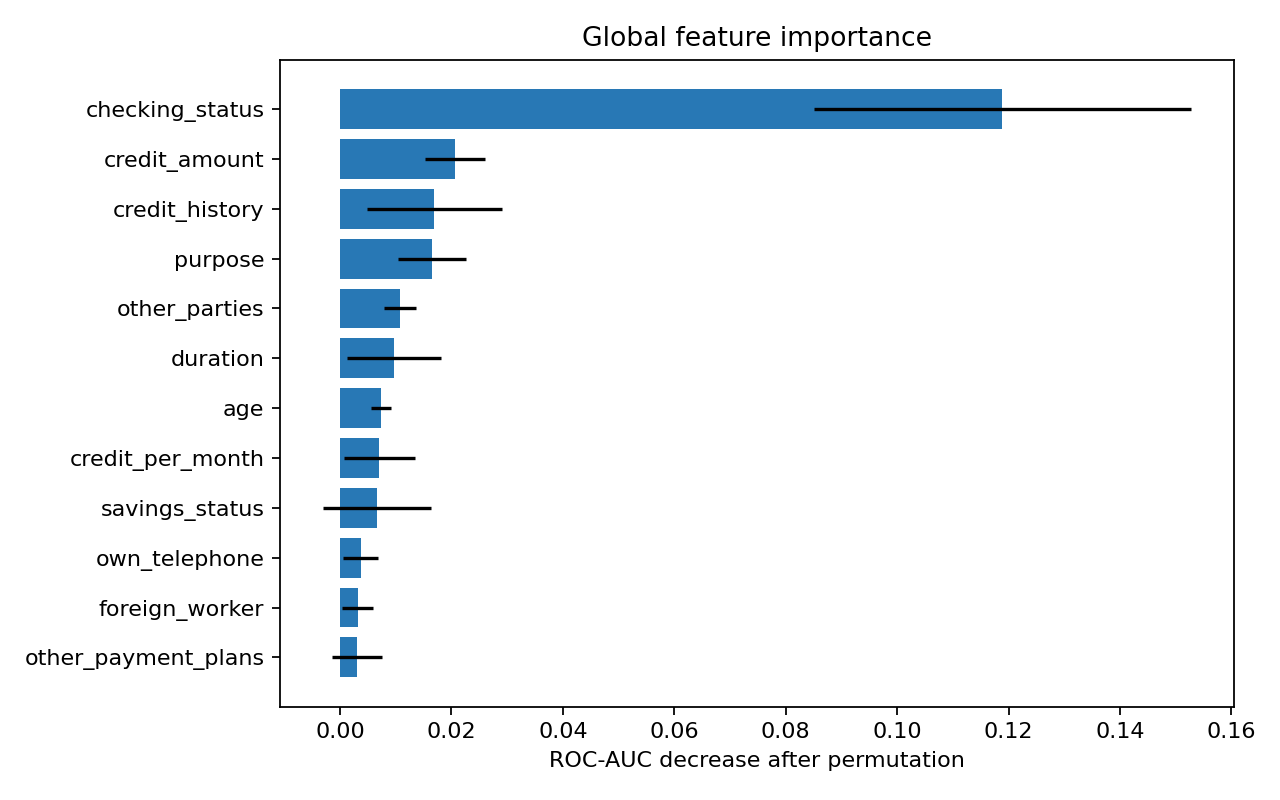

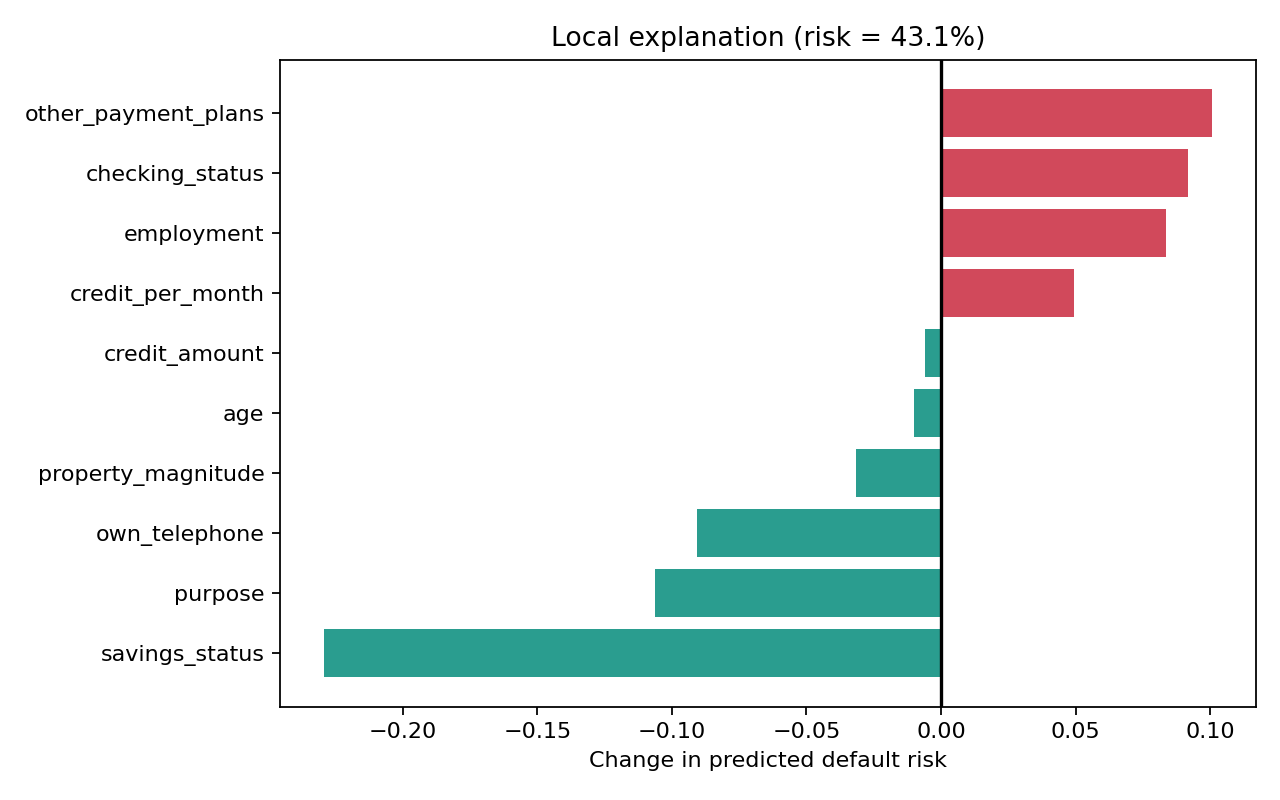

In [ ]:
# Q4 — global/local explanations and limited fairness audit
pi = permutation_importance(best, X_test, y_test, scoring="roc_auc", n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1)
importance = pd.DataFrame({"feature":X_test.columns, "importance":pi.importances_mean, "std":pi.importances_std}).sort_values("importance",ascending=False)
importance.to_csv(OUT / "global_feature_importance.csv",index=False)
display(importance.head(10))
top = importance.head(12).sort_values("importance")
plt.figure(figsize=(8,5)); plt.barh(top.feature,top.importance,xerr=top["std"],color="#2878B5"); plt.xlabel("ROC-AUC decrease after permutation"); plt.title("Global feature importance"); plt.tight_layout(); plt.savefig(FIG / "global_explanation.png",dpi=160); plt.show()

# Local explanation for one held-out record
row = X_test.iloc[[0]].copy(); base_risk = float(best.predict_proba(row)[:,1][0]); local=[]
for col in row.columns:
    changed = row.copy()
    changed[col] = X_train[col].median() if pd.api.types.is_numeric_dtype(X_train[col]) else X_train[col].mode().iloc[0]
    local.append({"feature":col,"value":str(row.iloc[0][col]),"risk_change":base_risk-float(best.predict_proba(changed)[:,1][0])})
local = pd.DataFrame(local).sort_values("risk_change",key=np.abs,ascending=False)
local.to_csv(OUT / "individual_explanation.csv",index=False)
display(local.head(10))
top_local = local.head(10).sort_values("risk_change")
plt.figure(figsize=(8,5)); plt.barh(top_local.feature,top_local.risk_change,color=np.where(top_local.risk_change>=0,"#D1495B","#2A9D8F")); plt.axvline(0,color="black"); plt.xlabel("Change in predicted default risk"); plt.title(f"Local explanation (risk = {base_risk:.1%})"); plt.tight_layout(); plt.savefig(FIG / "local_explanation.png",dpi=160); plt.show()

pred = best.predict(X_test); rows=[]
for group in sorted(g_test.unique()):
    mask = g_test == group
    rows.append({"group":group,"n":int(mask.sum()),"selection_rate":float(pred[mask].mean()),"default_recall":recall_score(y_test[mask],pred[mask],zero_division=0),"false_positive_rate":float(((pred[mask]==1)&(y_test[mask]==0)).sum()/max((y_test[mask]==0).sum(),1))})
fairness = pd.DataFrame(rows); fairness.to_csv(OUT / "fairness_audit.csv",index=False); display(fairness)


# 5. Product Pitch and Live Demo (2 marks)

**Video order:** Problem/beneficiaries → cleaning and feature → baseline vs ensembles → run the synthetic prediction below → explain risk and ethics.

Change only the two safe synthetic values and run the cell.

In [ ]:
# Q5 — live demo on a realistic synthetic record
record = X_test.iloc[[0]].copy()
requested_amount = 2500  # edit for the demo
repayment_months = 18    # edit for the demo
record["credit_amount"] = requested_amount
record["duration"] = repayment_months
record["credit_per_month"] = requested_amount / repayment_months
risk = float(best.predict_proba(record)[:,1][0])
print(f"Estimated default-risk signal: {risk:.1%}")
print("Human review required — this is not an approval or denial.")

# Updated local explanation for this demo record
live=[]
for col in record.columns:
    changed = record.copy(); changed[col] = X_train[col].median() if pd.api.types.is_numeric_dtype(X_train[col]) else X_train[col].mode().iloc[0]
    live.append((col, risk-float(best.predict_proba(changed)[:,1][0])))
live = pd.DataFrame(live,columns=["feature","risk_change"]).sort_values("risk_change",key=np.abs,ascending=False)
display(live.head(6))


# Summary

- The selected dataset is OpenML `credit-g` / UCI German Credit Data.
- The best model is selected by held-out test ROC-AUC after a baseline, bagging, boosting, stacking, and voting comparison.
- The solution includes data audit, leakage-safe pipeline, results, explanations, fairness audit, and a live synthetic prediction.
- It is an educational decision-support prototype only.